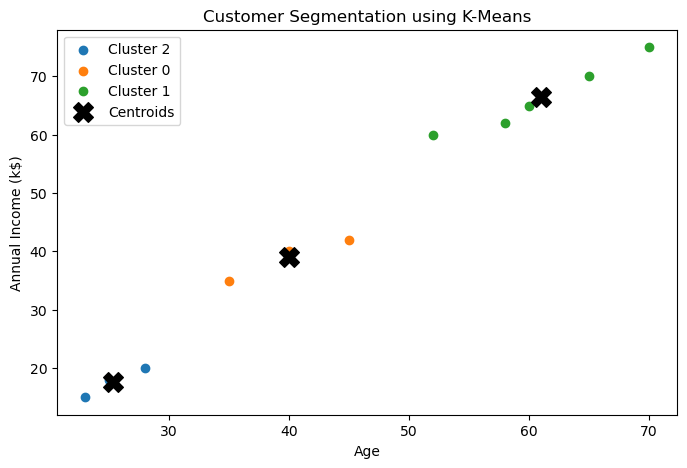

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Sample customer data
data = {
    'Age': [23, 25, 28, 35, 40, 45, 52, 58, 60, 65, 70],
    'Annual_Income(k$)': [15, 18, 20, 35, 40, 42, 60, 62, 65, 70, 75]
}
df = pd.DataFrame(data)

# Rename column to avoid special characters
df.rename(columns={'Annual_Income(k$)': 'Income'}, inplace=True)

# Ensure numeric
df['Age'] = pd.to_numeric(df['Age'])
df['Income'] = pd.to_numeric(df['Income'])

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
df['Cluster'] = kmeans.fit_predict(df[['Age', 'Income']])

# Visualize clusters
plt.figure(figsize=(8,5))
for cluster in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['Age'], cluster_data['Income'], label=f'Cluster {cluster}')

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='X', label='Centroids')

plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.title('Customer Segmentation using K-Means')
plt.legend()
plt.show()
